# Reaching the bSSFP steady state

Balanced SSFP acquires with a short, constant TR and returns every gradient axis to zero net area
over each RF-to-RF interval. Nothing is spoiled, so the transverse magnetisation left at the end
of one repetition is carried into the next, and after enough repetitions the train settles into a
repeating pattern — the **steady state** — whose signal is high and whose contrast goes roughly as
$\sqrt{T_2/T_1}$. That is what makes the sequence useful for cardiac cine, non-contrast
angiography and fast abdominal imaging.

Getting to that steady state is a separate matter from building a balanced waveform, and this
notebook is about the difference.

```text
balanced waveform   zero net gradient area on each axis over the RF-to-RF interval
                    true of the first interval the scanner ever plays

steady state        the magnetisation has settled into the pattern the train drives it to
                    develops over many repetitions, and depends on T1, T2, flip angle and TR
```

The build notebook beside this one measured the first: zero net area on every axis of every
interval, the echo at the declared TE, the requested line at the echo. **None of that says
anything about the magnetisation.** A sequence can be balanced, legal and compiled and still be
nowhere near steady state — which is why a bSSFP acquisition is preceded by a start-up schedule,
and why the opening repetitions of an unprepared train are unusable.

Here the train is simulated: first on single voxels, where the signal of every repetition can be
read off directly, then as an image.

In [1]:
import os

# MRzero's inner loop takes every thread it is offered.  Hold it to four.
os.environ.setdefault('OMP_NUM_THREADS', '4')
os.environ.setdefault('MKL_NUM_THREADS', '4')

import contextlib
import os as _os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import MRzeroCore as mr0
import numpy as np
import pypulseq as pp
import torch

import seqcraft as sc

torch.set_num_threads(4)
plt.rcParams['figure.dpi'] = 56

SEQ_DIR = Path('seq')
nominal = np.load(SEQ_DIR / 'bssfp_2d_nominal.npz')

MATRIX = tuple(int(v) for v in nominal['matrix'])
FOV_MM = float(nominal['fov_mm'])
THICKNESS_MM = float(nominal['thickness_mm'])
FLIP_DEG = float(nominal['flip_deg'])
BANDWIDTH_HZ_PX = float(nominal['bandwidth_hz_px'])
PHASE_STEP = float(nominal['phase_step'])
STARTUP = int(nominal['startup'])
SEGMENTS = int(nominal['segments'])
RECOVERY_S = float(nominal['recovery_s'])
TE_S, TR_S = float(nominal['te_s']), float(nominal['tr_s'])
CENTER_LINE = int(nominal['center_line'])
NX, NY = MATRIX

print(f'{NX} x {NY}, {FOV_MM:.0f} mm, {THICKNESS_MM:.0f} mm slice')
print(f'TE {TE_S * 1e3:.3f} ms   TR {TR_S * 1e3:.3f} ms   flip {FLIP_DEG:.0f} deg   '
      f'{STARTUP} start-up repetitions, {SEGMENTS} segments, '
      f'{RECOVERY_S * 1e3:.0f} ms recovery between them')
print(f'budget: {torch.get_num_threads()} torch threads')

sys.path.insert(0, str(Path('..').resolve()))
import phantom as ph            # noqa: E402

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


64 x 64, 250 mm, 6 mm slice
TE 3.425 ms   TR 6.850 ms   flip 40 deg   20 start-up repetitions, 4 segments, 400 ms recovery between them
budget: 4 torch threads


## 1. One voxel, one line, every repetition sampled

To watch the magnetisation settle, the signal has to be read at *every* repetition — including
the ones a real acquisition discards. So this section builds its own sequence: the same kernel,
TR, flip angle and 180° phase alternation, but with `ky` held at the centre line and every
repetition acquired.

Holding `ky` fixed means each repetition sees an identical gradient history, so what changes
between them is the magnetisation and nothing else. It also means none of these readouts is an
imaging readout — they are navigators on the magnetisation, and they say so with a `NAV` label.

Three tissues, spanning what a brain acquisition contains:

| | T1 (ms) | T2 (ms) | $\sqrt{T_2/T_1}$ | $3\,T_1$ |
|---|---|---|---|---|
| white matter | 830 | 80 | 0.31 | 2.5 s |
| grey matter | 1330 | 110 | 0.29 | 4.0 s |
| CSF | 4000 | 2000 | 0.71 | 12 s |

The last column is the scale on which $T_1$ recovery finishes, and it is already a warning: at
TR = 6.85 ms, three $T_1$ of white matter is some 360 repetitions.

In [2]:
opts = pp.Opts(
    max_grad=24, grad_unit='mT/m', max_slew=120, slew_unit='T/m/s', B0=3.0,
    rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6,
)
kernel = sc.modules.bSSFP2DTR(
    opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
    flip_deg=FLIP_DEG, bandwidth_hz_px=BANDWIDTH_HZ_PX,
)
assert abs(kernel.tr_s - TR_S) < 1e-12 and abs(kernel.te_s - TE_S) < 1e-12

N_REPS = 600          # 4.1 s of train: past three T1 for white and grey matter, not for CSF

#: These readouts all sit at one k-space address, so none of them is imaging.  Saying so keeps
#: them out of the duplicate-address check, which would otherwise be right to refuse the file.
NAV = pp.make_label(type='SET', label='NAV', value=1)

#: Filled in by `train`: what the alpha/2 preparation's gap came to.
HALF_GAP = [0.0]


def ramp_kernels(n, final_deg=FLIP_DEG):
    """A linear flip-angle ramp: n repetitions rising to the imaging angle."""
    return [
        sc.modules.bSSFP2DTR(
            opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
            flip_deg=final_deg * (k + 1) / (n + 1), bandwidth_hz_px=BANDWIDTH_HZ_PX,
            tr_s=TR_S,
        )
        for k in range(n)
    ]


#: The preparation pulse is shorter than the imaging pulse, and it has to be.  TR/2 has to hold
#: the preparation's own tail -- the second half of its envelope, its ringdown and its slice
#: rephaser -- plus the leading gradients of the first imaging repetition.  At TR = 6.85 ms the
#: imaging pulse's 3 ms does not fit in the 3.43 ms available; 1 ms does, with room to spare.
PREP_PULSE_S = 1e-3


def half_angle_prep(flip_deg=FLIP_DEG):
    """
    The alpha/2 pulse of the standard alpha/2 - TR/2 preparation, as a block of its own.

    A pulse, not a repetition: it excites and rebalances the slice axis and reads nothing.  The
    two z lobes are the ones a repetition carries, so the interval from this pulse's centre to
    the first imaging pulse's centre is balanced like any other.
    """
    exc = sc.modules.Excitation(opts=opts, flip_deg=flip_deg / 2, thickness_mm=THICKNESS_MM,
                                duration_s=PREP_PULSE_S)
    a_post = -exc.rephaser_area_per_m
    a_pre = float(exc.gz.area) - a_post
    lead = pp.make_trapezoid(channel='z', area=-a_pre, system=opts)
    lead_s = float(pp.calc_duration(lead))
    out = sc.LogicBlock('alpha_over_2')
    out.add(0.0, lead)
    out.add(lead_s, exc(rephase=True))
    return out, lead_s + exc.time_to_center()


def train(path, *, prep, reps=N_REPS, line=None):
    """
    `reps` imaging repetitions at one line, every one acquired, after a preparation.

    Returns the index of the first full-flip repetition, so the three strategies can be compared
    from the same instant: the opening point of a ramped train is a low-flip preparation pulse,
    not an imaging repetition, and lining them up at index 0 would compare different things.
    """
    line = CENTER_LINE if line is None else line
    out, at, n = sc.LogicBlock('transient'), 0.0, 0
    first = 0

    if prep == 'half-angle':
        block, to_centre = half_angle_prep()
        out.add(0.0, block)
        # Place the first imaging pulse so its RF centre falls TR/2 after the alpha/2 pulse's.
        # Every block starts on the gradient raster and TR/2 need not be a multiple of it, so
        # the gap is snapped up and what it actually came to is reported below.
        at = sc.Raster(opts.grad_raster_time).ceil(
            to_centre + TR_S / 2 - kernel.time_to_rf_center())
        HALF_GAP[0] = at + kernel.time_to_rf_center() - to_centre
        # The alpha/2 pulse takes the first slot in the phase alternation, so the first imaging
        # pulse is the second: it has to arrive 180 degrees out of phase with the preparation,
        # which is what makes the preparation leave the magnetisation where the train wants it.
        n = 1
    elif prep != 'none':
        for rep in ramp_kernels(int(prep)):
            out.add(at, rep(line=line, phase_deg=PHASE_STEP * n))
            out.add(at, NAV)
            at, n = at + rep.tr_s, n + 1
            first += 1

    for _ in range(reps):
        out.add(at, kernel(line=line, phase_deg=PHASE_STEP * n))
        out.add(at, NAV)
        at, n = at + kernel.tr_s, n + 1
    sc.compile(out, opts, name=path.stem).write(str(path))
    return first


PREPARATIONS = {'none': 'none', 'alpha/2 - TR/2': 'half-angle', f'{STARTUP}-step LFA': STARTUP}
FIRST = {}
for name, prep in PREPARATIONS.items():
    path = SEQ_DIR / f'bssfp_transient_{prep}.seq'
    FIRST[name] = train(path, prep=prep)
    print(f'{name:16} first full-flip repetition at index {FIRST[name]}')
print(f'\nalpha/2 pulse {PREP_PULSE_S * 1e3:.1f} ms; its centre to the first alpha centre is '
      f'{HALF_GAP[0] * 1e6:.1f} us against TR/2 = {TR_S / 2 * 1e6:.1f} us '
      f'({(HALF_GAP[0] - TR_S / 2) * 1e6:+.1f} us)')

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_61961/3040595036.py:96: SeqCraftWarning: 600 blocks over the vector-norm limit (legal on real amplifiers): transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 4.260 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 11.110 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 17.960 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 24.810 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 31.660 ms) (+595 more sites)
  sc.compile(out, opts, name=path.stem).write(str(path))


none             first full-flip repetition at index 0


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_61961/3040595036.py:96: SeqCraftWarning: 600 blocks over the vector-norm limit (legal on real amplifiers): transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 6.770 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 13.620 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 20.470 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 27.320 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 34.170 ms) (+595 more sites)
  sc.compile(out, opts, name=path.stem).write(str(path))


alpha/2 - TR/2   first full-flip repetition at index 0


20-step LFA      first full-flip repetition at index 20

alpha/2 pulse 1.0 ms; its centre to the first alpha centre is 3430.0 us against TR/2 = 3425.0 us (+5.0 us)


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_61961/3040595036.py:96: SeqCraftWarning: 620 blocks over the vector-norm limit (legal on real amplifiers): transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 4.260 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 11.110 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 17.960 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 24.810 ms), transient.bSSFP2DTR, transient.bSSFP2DTR.CartesianLine, transient.bSSFP2DTR.PhaseEncode (slew 135% at 31.660 ms) (+615 more sites)
  sc.compile(out, opts, name=path.stem).write(str(path))


In [3]:
TISSUES = {
    'white matter': dict(T1=0.83, T2=0.080),
    'grey matter':  dict(T1=1.33, T2=0.110),
    'CSF':          dict(T1=4.00, T2=2.000),
}


def one_voxel(T1, T2, B0=0.0):
    """A single on-resonance spin, so each repetition returns one complex number."""
    return mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=1.0, T1=T1, T2=T2, T2dash=1e3, D=0.0, B0=B0,
        voxel_size=0.1, voxel_shape='box',
    ).build()


@contextlib.contextmanager
def quiet():
    """
    Silence the solver's per-call timing log.

    It is written from MRzero's Rust extension straight to file descriptor 1, so redirecting
    Python's ``sys.stdout`` does not catch it -- the descriptor itself has to be moved.
    """
    saved = _os.dup(1)
    null = _os.open(_os.devnull, _os.O_WRONLY)
    try:
        _os.dup2(null, 1)
        yield
    finally:
        _os.dup2(saved, 1)
        _os.close(null)
        _os.close(saved)


def echo_train(path, obj):
    """|signal| at the echo sample of each repetition."""
    seq = mr0.Sequence.import_file(str(path))
    with quiet():
        graph = mr0.compute_graph(seq, obj, max_state_count=200, min_state_mag=1e-5)
        signal = np.asarray(mr0.execute_graph(graph, seq, obj, print_progress=False).cpu())
    rows = signal.reshape(-1, int(kernel.ro.adc.num_samples))
    return rows[:, kernel.ro.echo_sample(0)]


#: ``full[preparation][tissue]`` -- every acquired repetition, preparation pulses included.
full = {
    name: {tissue: echo_train(SEQ_DIR / f'bssfp_transient_{prep}.seq', one_voxel(**t))
           for tissue, t in TISSUES.items()}
    for name, prep in PREPARATIONS.items()
}
#: ``signal[...]`` -- the same, trimmed to start at the first full-flip imaging repetition.
signal = {name: {tissue: s[FIRST[name]:] for tissue, s in d.items()}
          for name, d in full.items()}
print({name: (len(full[name]['white matter']), len(signal[name]['white matter']))
       for name in PREPARATIONS})

{'none': (600, 600), 'alpha/2 - TR/2': (600, 600), '20-step LFA': (620, 600)}


### The preparation itself

The preparation pulses are acquired here too, so the first view is the whole history on a linear
axis: what each scheme does to the magnetisation before the imaging train starts.

```text
none              a, a, a, ...
alpha/2 - TR/2    a/2, then TR/2, then a, a, a, ...
20-step LFA       a1 ... a20 rising to a, then a, a, a, ...
```

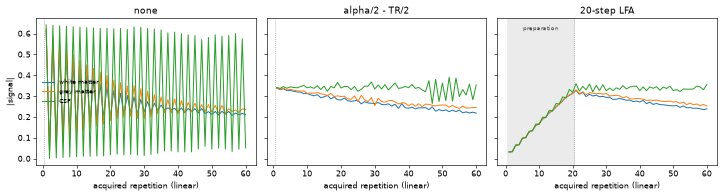

The alpha/2 scheme has one preparation pulse and it is not acquired as an imaging
repetition; the LFA scheme has 20. The dotted line marks the first full-flip repetition.
  none             600 acquired, first full-flip at index 0, |S| there 0.6158
  alpha/2 - TR/2   600 acquired, first full-flip at index 0, |S| there 0.3384
  20-step LFA      620 acquired, first full-flip at index 20, |S| there 0.3275


In [4]:
fig, axes = plt.subplots(1, len(PREPARATIONS), figsize=(13, 3.6), sharey=True)
SHOW = 60
for ax, name in zip(axes, PREPARATIONS):
    first = FIRST[name]
    for tissue, s in full[name].items():
        ax.plot(np.arange(len(s[:SHOW])) + 1, np.abs(s[:SHOW]), lw=1.3, label=tissue)
    if first:
        ax.axvspan(0.5, first + 0.5, color='0.92', zorder=0)
        ax.text(first / 2 + 0.5, ax.get_ylim()[1] * 0.95, 'preparation',
                ha='center', va='top', fontsize=8, color='0.35')
    ax.axvline(first + 0.5, color='0.6', lw=1.0, ls=':')
    ax.set_title(name)
    ax.set_xlabel('acquired repetition (linear)')
axes[0].set_ylabel('|signal|')
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

print('The alpha/2 scheme has one preparation pulse and it is not acquired as an imaging')
print('repetition; the LFA scheme has 20. The dotted line marks the first full-flip repetition.')
for name in PREPARATIONS:
    s = full[name]['white matter']
    print(f'  {name:16} {len(s)} acquired, first full-flip at index {FIRST[name]}, '
          f'|S| there {np.abs(s[FIRST[name]]):.4f}')

The grey band is the preparation. The `alpha/2` scheme spends one pulse there and the LFA
scheme twenty; "none" spends none and opens at the full flip angle straight from equilibrium.

What that view answers is *what the preparation did*. What it cannot answer is what the
acquisition sees, because the three schemes reach their first imaging repetition at different
points on the horizontal axis. That is the next figure.

### The imaging train, aligned after preparation

### The approach to steady state

Every repetition below plays an identical, balanced waveform. The signal is not identical,
because the magnetisation is still moving.

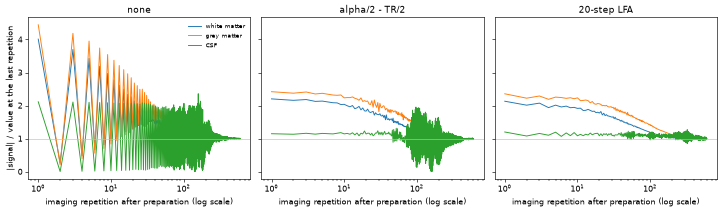

In [5]:
# Repetition 1 is the first full-flip imaging repetition after the selected preparation, so the
# alpha/2 pulse and the 20 LFA pulses do not count on this axis.
fig, axes = plt.subplots(1, len(PREPARATIONS), figsize=(13, 3.9), sharey=True)
for ax, name in zip(axes, PREPARATIONS):
    for tissue, s in signal[name].items():
        ax.plot(np.arange(len(s)) + 1, np.abs(s) / np.abs(s[-1]), lw=1.2, label=tissue)
    ax.axhline(1.0, color='0.75', lw=0.8)
    ax.set_xscale('log')
    ax.set_title(name)
    ax.set_xlabel('imaging repetition after preparation (log scale)')
axes[0].set_ylabel('|signal| / value at the last repetition')
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

In [6]:
def within(s, tol=0.05):
    """First repetition after which |S| stays within `tol` of its final value, or None."""
    final = np.abs(s[-1])
    bad = np.nonzero(np.abs(np.abs(s) - final) / final > tol)[0]
    n = int(bad[-1]) + 2 if len(bad) else 1
    return n if n <= len(s) else None


def predicted_decay(T1, T2, flip_deg=FLIP_DEG, tr_s=TR_S):
    """
    Scheffler 2003 Eq. [7]: the transient decays as lambda1**n, with

        lambda1 = E2 sin^2(alpha/2) + E1 cos^2(alpha/2),   E1,2 = exp(-TR / T1,2)

    derived there for the alpha/2 - TR/2 prepared case.  It depends on the tissue, the flip angle
    and TR -- and on nothing the preparation does, which is the point of putting it beside the
    measured columns.
    """
    a = np.deg2rad(flip_deg)
    e1, e2 = np.exp(-tr_s / T1), np.exp(-tr_s / T2)
    return e2 * np.sin(a / 2) ** 2 + e1 * np.cos(a / 2) ** 2


marks = (1, 5, 20, 100, 300)
print('|S| relative to the last repetition, counted from the first imaging repetition\n')
print(f'{"tissue":14}' + ''.join(f'{f"rep {m}":>9}' for m in marks)
      + f'{"within 5%":>11}{"Scheffler":>11}')
for name in PREPARATIONS:
    print(f'\n-- {name}')
    for tissue, t in TISSUES.items():
        s = signal[name][tissue]
        final = np.abs(s[-1])
        got = within(s)
        lam = predicted_decay(t['T1'], t['T2'])
        print(f'{tissue:14}'
              + ''.join(f'{np.abs(s[m - 1]) / final:9.2f}' for m in marks)
              + (f'{got:11d}' if got else f'{"> " + str(len(s)):>11}')
              + f'{np.log(0.05) / np.log(lam):11.0f}')
print(f'\n{N_REPS} imaging repetitions is {N_REPS * TR_S:.2f} s of train.')
print('The last column is log(0.05)/log(lambda1) -- how many repetitions Scheffler Eq. [7]')
print('predicts for the transient to fall to 5% of its initial size.')

|S| relative to the last repetition, counted from the first imaging repetition

tissue            rep 1    rep 5   rep 20  rep 100  rep 300  within 5%  Scheffler

-- none
white matter       4.01     3.43     1.29     1.19     1.01        175        176
grey matter        4.44     3.95     1.31     1.39     1.03        267        257
CSF                2.12     2.10     0.06     0.10     0.94        402       1566

-- alpha/2 - TR/2
white matter       2.20     2.14     1.83     1.20     1.01        167        176
grey matter        2.42     2.37     2.13     1.43     1.03        256        257
CSF                1.15     1.16     1.14     0.13     0.83        419       1566

-- 20-step LFA
white matter       2.13     2.01     1.77     1.19     1.01        175        176
grey matter        2.36     2.26     2.05     1.40     1.03        269        257
CSF                1.20     1.20     1.09     0.96     1.19        569       1566

600 imaging repetitions is 4.11 s of train.
The last co

**The waveform was balanced in every one of those repetitions, and the magnetisation was settled
in none of the early ones.** All three traces start at the first repetition played at the imaging
flip angle, so they are comparable: the opening point of a ramped train is a low-flip preparation
pulse rather than an imaging repetition, and lining the traces up at index 0 would compare
different things.

```text
literature        Scheffler 2003 writes the transient as M(n) = (sin(alpha/2) M0 - Mss) lambda1^n
                  + Mss.  The preparation sets the amplitude of the first term; lambda1 -- the
                  rate -- depends only on T1, T2, the flip angle and TR.

measured          white matter, |S| at the first imaging repetition relative to the last:
                      none 4.01, alpha/2 2.20, 20-step LFA 2.13.
                  repetitions to stay within 5%:
                      none 175, alpha/2 167, 20-step LFA 175,
                  against 176 predicted by Eq. [7] for this tissue and protocol.

interpretation    both preparations roughly halve the opening excursion and neither changes the
                  convergence rate, which is what Eq. [7] says should happen: a preparation can
                  move the starting point and not the decay constant.  The measured and
                  predicted columns agree for white and grey matter.  They do not for CSF,
                  because its predicted transient outlasts the 600-repetition window and the
                  "final" value the measurement normalises by is not a steady state.
```

Transient suppression and convergence to the steady state are therefore different things, and
these preparations do the first. Twenty LFA repetitions is a demonstration choice; the scheme is
Deshpande's, and nothing here establishes a number that transfers to another protocol.

The `alpha/2 - TR/2` scheme is the one Scheffler analyses: a pulse of half the imaging angle, half a TR
before the train, which places the magnetisation near the axis the steady state precesses about.
The linear flip-angle ramp approaches the same place over 20 repetitions instead.

20 repetitions is a **preparation choice**, not a claim that the magnetisation has reached steady
state. The table shows it has not: the "within 5%" column is in the hundreds for every tissue.

CSF does not settle inside this window at all -- $3\,T_1$ is 12 s where the train is 4 s -- so its
row measures how far it has got rather than where it ends up.

Two things that are **not** evidence of steady state, and that the build notebook establishes
instead:

```text
M0 = 0 over every RF-to-RF interval     the waveform is balanced
timing is legal and the file compiles   the sequence can be played
```

Both are true from repetition 1 of every train above.

### Off-resonance: the other thing TE = TR/2 is for

Because nothing is spoiled, phase accrued from off-resonance during one TR is carried into the
next, so the steady state is a function of the off-resonance angle per TR,
$\theta = 2\pi\,\Delta f\,\mathrm{TR}$. It collapses where $\theta$ approaches $\pm\pi$ -- the dark
bands bSSFP is known for, spaced $1/\mathrm{TR}$ apart in frequency.

White and grey matter only: CSF has not settled by the end of this train, so a steady-state
response is not something that can be read off it here.

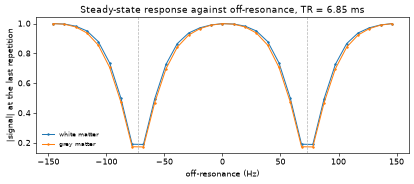

offsets sampled every 9.7 Hz; +/- 1/(2 TR) = 73.0 Hz
white matter   deepest sampled point at  +77.9 Hz, 0.50 grid steps from the nearer of +/- 1/(2 TR)
grey matter    deepest sampled point at  -68.1 Hz, 0.50 grid steps from the nearer of +/- 1/(2 TR)


In [7]:
offsets_hz = np.linspace(-1.0 / TR_S, 1.0 / TR_S, 31)
profile = {
    name: np.array([
        np.abs(echo_train(SEQ_DIR / f'bssfp_transient_{STARTUP}.seq',
                          one_voxel(**t, B0=f))[-1])
        for f in offsets_hz
    ])
    for name, t in TISSUES.items() if name != 'CSF'
}

fig, ax = plt.subplots(figsize=(7.5, 3.4))
for name, s in profile.items():
    ax.plot(offsets_hz, s / s.max(), lw=1.3, marker='.', ms=4, label=name)
for edge in (-0.5 / TR_S, 0.5 / TR_S):
    ax.axvline(edge, color='0.7', ls='--', lw=0.9)
ax.set_xlabel('off-resonance (Hz)')
ax.set_ylabel('|signal| at the last repetition')
ax.set_title(f'Steady-state response against off-resonance, TR = {TR_S * 1e3:.2f} ms')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

step = offsets_hz[1] - offsets_hz[0]
print(f'offsets sampled every {step:.1f} Hz; +/- 1/(2 TR) = {0.5 / TR_S:.1f} Hz')
for name, s in profile.items():
    null = offsets_hz[np.argmin(s)]
    print(f'{name:14} deepest sampled point at {null:+6.1f} Hz, '
          f'{abs(abs(null) - 0.5 / TR_S) / step:.2f} grid steps from the nearer of '
          f'+/- 1/(2 TR)')

The passband is centred on resonance and the response falls away towards $\pm 1/(2\,\mathrm{TR})$,
where the off-resonance phase per TR reaches $\pm\pi$ — the placement the 180° alternation
produces. The two curves differ in how flat the passband is, which is where $T_1$, $T_2$ and the
flip angle enter.

This is measured on single on-resonance-plus-offset voxels with no intravoxel spread; a real
voxel contains a distribution of off-resonance, so a band in an image is an average over that
distribution rather than the curve above.

## 2. The acquisition, reconstructed

Now the two sequences the build notebook wrote. Both acquire the same 64 lines; they differ in
where the start-up schedules fall:

```text
continuous    one 20-step ramp, then all 64 lines
segmented     four groups of 16, each preceded by its own 20-step ramp, with 400 ms of
              recovery between groups -- the interrupted policy
```

A BrainWeb slab stands in for the object. The phantom is a **slab** rather than a single slice
because the excitation's selection gradient dephases across the slice; with one voxel along z
there is nothing to average that dephasing over and the simulator returns zero.

In [8]:
NZ, N_COILS = 4, 8
obj = ph.built(matrix=NX, nz=NZ, n_coils=N_COILS)
lines = [int(v) for v in nominal['lines']]

print(f'{NX} x {NX} x {NZ} voxels, {N_COILS} coils; the sequence excites '
      f'{THICKNESS_MM:.0f} mm at isocentre')
print(f'{len(lines)} lines, acquired in the order they were written')

64 x 64 x 4 voxels, 8 coils; the sequence excites 6 mm at isocentre
64 lines, acquired in the order they were written


In [9]:
def to_grid(signal, lines):
    """``(coil, ky, kx)`` from the flat signal: one row per repetition, in acquisition order."""
    n = int(kernel.ro.adc.num_samples)
    rows = np.asarray(signal).reshape(len(lines), n, -1)
    out = np.zeros((rows.shape[2], NY, NX), dtype=np.complex64)
    for index, line in enumerate(lines):
        out[:, line, :] = rows[index].T
    return out


def acquire(path, obj, lines):
    """Play a file and return ``(k-space, root-sum-of-squares image)``."""
    seq = mr0.Sequence.import_file(str(path))
    with quiet():
        graph = mr0.compute_graph(seq, obj, max_state_count=200, min_state_mag=1e-4)
        signal = np.asarray(mr0.execute_graph(graph, seq, obj, print_progress=False).cpu())
    k = to_grid(signal, lines)
    images = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k, axes=(-2, -1))), axes=(-2, -1))
    return k, np.sqrt((np.abs(images) ** 2).sum(axis=0))


k_cont, image = acquire(SEQ_DIR / 'bssfp_2d.seq', obj, lines)
k_seg, segmented = acquire(SEQ_DIR / 'bssfp_2d_segmented.seq', obj, lines)
print(f'image {image.shape}, k-space {k_cont.shape}')

image (64, 64), k-space (8, 64, 64)


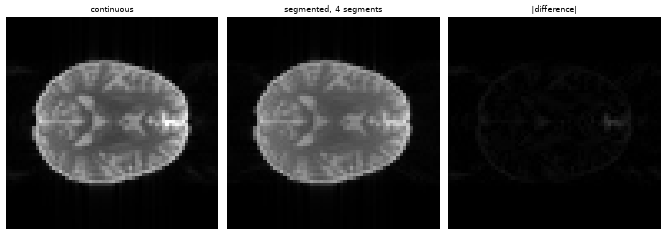

largest difference: 21.1% of the continuous image peak


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
top = max(image.max(), segmented.max())
for ax, (title, data, vmax) in zip(axes, (
    ('continuous', image, top),
    (f'segmented, {SEGMENTS} segments', segmented, top),
    ('|difference|', np.abs(image - segmented), top),
)):
    ax.imshow(data.T, cmap='gray', origin='lower', vmin=0, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
fig.tight_layout()
plt.show()

rel = np.abs(image - segmented).max() / image.max()
print(f'largest difference: {rel * 100:.1f}% of the continuous image peak')

The two acquisitions encode the same lines, and the difference is large rather than subtle. §1
is why: twenty ramp repetitions are nowhere near settling any of these tissues, so every segment
is acquired during a transient, and the segmented acquisition restarts that transient three extra
times after 400 ms of recovery.

To see what that does to k-space without the object's own structure confounding it, the next cell
repeats both acquisitions on a **single-tissue** phantom — one $T_1$ and $T_2$ everywhere. Then
the only thing that differs between the two at a given line is where that line fell in its train.

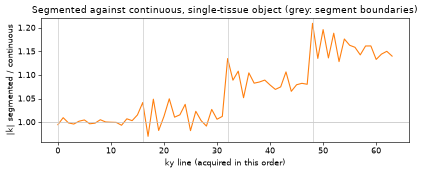

ratio ranges 0.97 to 1.21 over ky
  segment 0: lines  0-15  ratio 0.99 to 1.02
  segment 1: lines 16-31  ratio 0.97 to 1.05
  segment 2: lines 32-47  ratio 1.05 to 1.13
  segment 3: lines 48-63  ratio 1.13 to 1.21


In [11]:
# A single-tissue object, so the comparison below is a statement about the magnetisation and
# not about which tissues happen to sit at which ky.  With one T1/T2 everywhere, the only thing
# that differs between the two acquisitions at a given line is where it fell in the train.
uniform = ph.slab(matrix=NX, nz=NZ, n_coils=N_COILS)
for field in ('T1', 'T2', 'T2dash', 'D', 'B0'):
    m = getattr(uniform, field, None)
    if m is not None:
        setattr(uniform, field, torch.full_like(m, {'T1': 0.83, 'T2': 0.08, 'T2dash': 0.05,
                                                    'D': 0.0, 'B0': 0.0}[field]))
uniform_obj = uniform.build()

k_cont_u, _ = acquire(SEQ_DIR / 'bssfp_2d.seq', uniform_obj, lines)
k_seg_u, _ = acquire(SEQ_DIR / 'bssfp_2d_segmented.seq', uniform_obj, lines)

cont_line = np.abs(k_cont_u[:, :, NX // 2]).sum(axis=0)
seg_line = np.abs(k_seg_u[:, :, NX // 2]).sum(axis=0)
ratio = seg_line / cont_line

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.plot(ratio, lw=1.4, color='C1')
ax.axhline(1.0, color='0.75', lw=0.9)
for boundary in range(0, NY, NY // SEGMENTS):
    ax.axvline(boundary, color='0.8', lw=0.9)
ax.set_xlabel('ky line (acquired in this order)')
ax.set_ylabel('|k| segmented / continuous')
ax.set_title('Segmented against continuous, single-tissue object '
             '(grey: segment boundaries)')
fig.tight_layout()
plt.show()

print(f'ratio ranges {ratio.min():.2f} to {ratio.max():.2f} over ky')
for seg in range(SEGMENTS):
    lo = seg * (NY // SEGMENTS)
    chunk = ratio[lo:lo + NY // SEGMENTS]
    print(f'  segment {seg}: lines {lo:2d}-{lo + NY // SEGMENTS - 1:2d}  '
          f'ratio {chunk.min():.2f} to {chunk.max():.2f}')

```text
measured          the ratio by segment, on a single-tissue object

interpretation    the first segment nearly matches the continuous acquisition, because both
                  start from equilibrium and run the same 20-step ramp.  Later segments diverge:
                  by the time the continuous train reaches those lines it has had dozens more
                  repetitions to converge, while the segmented one has recovered towards
                  equilibrium during the gap and restarted its transient.
```

Neither acquisition is less balanced than the other — that holds interval by interval in both,
and the build notebook measures it. What differs is the magnetisation when each line was
acquired.

For this protocol and this ordering, the remedies are all acquisition policy: a longer
preparation, a centre-ordered `ky` table so the transient lands on the k-space periphery, fewer
segments, or the maintained policy instead of the interrupted one.

In [12]:
mask = ph.same_frame(ph.mask(matrix=NX, nz=NZ)[..., NZ // 2])
print(f'{"":14}{"mean |S| in tissue":>20}{"std":>10}')
for name, data in (('continuous', image), ('segmented', segmented)):
    v = data[mask]
    print(f'{name:14}{v.mean():20.4f}{v.std():10.4f}')

                mean |S| in tissue       std
continuous                  0.8140    0.6859
segmented                   0.7916    0.6499


## 3. What this notebook did and did not establish

**Established, by simulation:**

- Every repetition of every train above plays the same balanced waveform, and the signal still
  changes from one to the next until the magnetisation settles. Balance and steady state are
  separate properties, and only the first is a property of the file.
- An unprepared train opens about four times above its final value. Both an `α/2 – TR/2` pulse
  and a 20-step flip-angle ramp roughly halve that, and neither changes the convergence rate —
  which is what Scheffler's Eq. [7] predicts, since the rate depends on $T_1$, $T_2$, the flip
  angle and TR and not on the preparation.
- The steady-state response against off-resonance falls away towards $\pm 1/(2\,\mathrm{TR})$,
  where the phase per TR reaches $\pm\pi$ under the 180° alternation used here.
- A segmented acquisition encodes the same lines as a continuous one, and repeats the start-up
  transient once per segment, which with linear `ky` ordering appears as a modulation across
  k-space.

**Not established here:**

- How many start-up repetitions a protocol needs. The numbers above are for these tissues, this
  flip angle and this TR, and 20 is a demonstration choice rather than a derived count.
- Which start-up schedule is best. Two are simulated at one setting each, on one protocol.
- What a centre-ordered or interleaved `ky` table would do to the segmented image. Those are
  edits to the build notebook's two loops, and none of them is measured here.
- Anything about a real scanner. MRzero applies each pulse as a rotation by its integrated
  envelope, the phantom's $B_0$ map is synthesised rather than measured, and each simulated voxel
  carries a single off-resonance value rather than a distribution.

## Summary

- A balanced waveform is true from the first RF-to-RF interval. A steady state develops over
  repetitions, on a timescale set by $T_1$.
- `M0 = 0`, legal timing and a successful compile establish the first and say nothing about the
  second.
- The start-up schedule, the `ky` ordering and the segmentation are acquisition policy, written
  in the notebook rather than in the kernel — and in this protocol they are what the image
  quality turns on.

## References

1. Carr HY. *Steady-state free precession in nuclear magnetic resonance.* Phys Rev 1958;112:1693.
2. Scheffler K, Lehnhardt S. *Principles and applications of balanced SSFP techniques.* Eur Radiol
   2003;13:2409.
3. Bieri O, Scheffler K. *Fundamentals of balanced steady state free precession MRI.* J Magn Reson
   Imaging 2013;38:2.
4. Deshpande VS, Chung YC, Zhang Q, Shea SM, Li D. *Reduction of transient signal oscillations in
   true-FISP using a linear flip angle series magnetization preparation.* Magn Reson Med
   2003;49:151.
5. Bernstein MA, King KF, Zhou XJ. *Handbook of MRI Pulse Sequences.* Elsevier, 2004, §14.1.